# Análisis Avanzado de Patrones y Combinaciones

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# 1. Creación de Métricas (7 features)

En esta sección se crean nuevas métricas (features) derivadas de los datos originales del dataset de accidentes de tráfico. Estas métricas permiten un análisis más profundo y facilitan la identificación de patrones que no son evidentes en las variables originales. Todas las métricas están respaldadas por literatura académica y estudios previos sobre seguridad vial.

In [9]:
# Cargar dataset limpio
df = pd.read_csv('accidents_2022_clean2.csv')
df['Start_Time'] = pd.to_datetime(df['Start_Time'])

1. Region - Permite análisis geográfico regional

In [10]:
# Feature 1: Región Geográfica (US Census)
print("\n1. REGIÓN GEOGRÁFICA (US Census Bureau):")
def assign_census_region(state):
    """Asigna región según clasificación del US Census Bureau"""
    regions = {
        'Northeast': ['ME','NH','VT','MA','RI','CT','NY','NJ','PA'],
        'Midwest': ['OH','IN','IL','MI','WI','MN','IA','MO','ND','SD','NE','KS'],
        'South': ['DE','MD','VA','WV','NC','SC','GA','FL','KY','TN','AL','MS','AR','LA','OK','TX','DC'],
        'West': ['MT','ID','WY','CO','NM','AZ','UT','NV','WA','OR','CA','AK','HI']
    }

    for region, states in regions.items():
        if state in states:
            return region
    return 'Unknown'

df['Region'] = df['State'].apply(assign_census_region)
region_counts = df['Region'].value_counts()
print(f"Distribución por región:")
for region, count in region_counts.items():
    print(f"      {region}: {count:,} accidentes ({count/len(df)*100:.1f}%)")
print(f"Ref: US Census Bureau (2020)")


1. REGIÓN GEOGRÁFICA (US Census Bureau):
Distribución por región:
      South: 818,216 accidentes (46.4%)
      West: 523,355 accidentes (29.7%)
      Northeast: 246,556 accidentes (14.0%)
      Midwest: 174,322 accidentes (9.9%)
Ref: US Census Bureau (2020)


2. Severity_Category - Simplifica comparaciones binarias

In [11]:
# Feature 2: Categoría de Severidad
print("\n2. CATEGORÍA DE SEVERIDAD:")
def categorize_severity(severity):
    if severity <= 2:
        return 'Baja'
    else:
        return 'Alta'

df['Severity_Category'] = df['Severity'].apply(categorize_severity)
sev_counts = df['Severity_Category'].value_counts()
print(f"   - Severidad Baja (1-2): {sev_counts.get('Baja', 0):,} ({sev_counts.get('Baja', 0)/len(df)*100:.1f}%)")
print(f"   - Severidad Alta (3-4): {sev_counts.get('Alta', 0):,} ({sev_counts.get('Alta', 0)/len(df)*100:.1f}%)")


2. CATEGORÍA DE SEVERIDAD:
   - Severidad Baja (1-2): 1,641,218 (93.1%)
   - Severidad Alta (3-4): 121,231 (6.9%)


3. POI_Count & POI_Density - Cuantifica complejidad de infraestructura

In [12]:
# Feature 3: Conteo de POIs (infraestructura)
print("\n3. CONTEO DE POIs (Points of Interest):")
poi_columns = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
               'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
               'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

df['POI_Count'] = df[poi_columns].sum(axis=1)
print(f"   - Rango de POIs: {df['POI_Count'].min()} - {df['POI_Count'].max()}")
print(f"   - Promedio de POIs por accidente: {df['POI_Count'].mean():.2f}")
print(f"   - Mediana de POIs: {df['POI_Count'].median():.0f}")

# Categorizar
def categorize_poi_density(count):
    if count == 0: return 'Sin POIs'
    elif count <= 2: return 'Baja'
    elif count <= 4: return 'Media'
    else: return 'Alta'

df['POI_Density'] = df['POI_Count'].apply(categorize_poi_density)
print(f"   - Distribución de densidad de POIs:")
for density, count in df['POI_Density'].value_counts().items():
    print(f"      {density}: {count:,} ({count/len(df)*100:.1f}%)")
print(f"Ref: Abdel-Aty & Radwan (2000)")


3. CONTEO DE POIs (Points of Interest):
   - Rango de POIs: 0 - 7
   - Promedio de POIs por accidente: 0.33
   - Mediana de POIs: 0
   - Distribución de densidad de POIs:
      Sin POIs: 1,340,065 (76.0%)
      Baja: 397,967 (22.6%)
      Media: 23,769 (1.3%)
      Alta: 648 (0.0%)
Ref: Abdel-Aty & Radwan (2000)


4. Visibility_Category - Categoriza condiciones de visibilidad

In [13]:
# Feature 4: Índice de Visibilidad (simplificado)
print("\n4. ÍNDICE DE VISIBILIDAD:")
def categorize_visibility(vis):
    if pd.isna(vis):
        return 'Desconocido'
    elif vis < 1:
        return 'Muy Baja'
    elif vis < 5:
        return 'Baja'
    elif vis < 10:
        return 'Media'
    else:
        return 'Alta'

df['Visibility_Category'] = df['Visibility(mi)'].apply(categorize_visibility)
print(f"   - Distribución de visibilidad:")
for cat, count in df['Visibility_Category'].value_counts().items():
    print(f"      {cat}: {count:,} ({count/len(df)*100:.1f}%)")
print(f"Ref: FHWA (2020) - Weather Impact")

# Guardar
df.to_csv('accidents_features_p2.csv', index=False)


4. ÍNDICE DE VISIBILIDAD:
   - Distribución de visibilidad:
      Alta: 1,479,324 (83.9%)
      Media: 151,893 (8.6%)
      Baja: 103,347 (5.9%)
      Muy Baja: 27,885 (1.6%)
Ref: FHWA (2020) - Weather Impact


In [14]:
# Cargar dataset
df = pd.read_csv('accidents_features_p2.csv')
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['End_Time'] = pd.to_datetime(df['End_Time'], format='mixed')


5. Duration_Minutes & Duration_Category - Mide impacto operacional

In [15]:
# Feature 5: Duración del Impacto
print("\n1. DURACIÓN DEL IMPACTO:")
df['Duration_Minutes'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60

# Limpiar valores negativos o muy altos
df.loc[df['Duration_Minutes'] < 0, 'Duration_Minutes'] = np.nan
df.loc[df['Duration_Minutes'] > 1440, 'Duration_Minutes'] = 1440  # Cap a 24 horas

print(f"   -Duración promedio: {df['Duration_Minutes'].mean():.1f} minutos")
print(f"   -Duración mediana: {df['Duration_Minutes'].median():.1f} minutos")
print(f"   -Duración mínima: {df['Duration_Minutes'].min():.1f} minutos")
print(f"   -Duración máxima: {df['Duration_Minutes'].max():.1f} minutos")

# Categorizar
df['Duration_Category'] = pd.cut(df['Duration_Minutes'],
                                  bins=[0, 30, 60, 120, 240, 1440],
                                  labels=['Muy Corta (<30min)', 'Corta (30-60min)',
                                          'Media (1-2h)', 'Larga (2-4h)', 'Muy Larga (>4h)'])

print(f"\n   Distribución por duración:")
for cat, count in df['Duration_Category'].value_counts().sort_index().items():
    print(f"      {cat}: {count:,} ({count/len(df)*100:.1f}%)")
print(f"Ref: FHWA (2010) - Traffic Incident Management")


1. DURACIÓN DEL IMPACTO:
   -Duración promedio: 173.6 minutos
   -Duración mediana: 122.8 minutos
   -Duración mínima: 3.0 minutos
   -Duración máxima: 1440.0 minutos

   Distribución por duración:
      Muy Corta (<30min): 190,218 (10.8%)
      Corta (30-60min): 169,030 (9.6%)
      Media (1-2h): 488,949 (27.7%)
      Larga (2-4h): 324,753 (18.4%)
      Muy Larga (>4h): 589,499 (33.4%)
Ref: FHWA (2010) - Traffic Incident Management


6.  Urban_Rural - Clasifica contexto geográfico

In [16]:
# Feature 6: Clasificación Urbano/Rural
print("\n2. CLASIFICACIÓN URBANO/RURAL:")
def classify_urban_rural(row):
    """Clasifica basándose en distancia afectada y POIs"""
    if row['Distance(mi)'] < 0.5 and row['POI_Count'] >= 2:
        return 'Urbano'
    elif row['Distance(mi)'] > 2 or row['POI_Count'] == 0:
        return 'Rural'
    else:
        return 'Suburbano'

df['Urban_Rural'] = df.apply(classify_urban_rural, axis=1)

print(f"   - Distribución:")
for area, count in df['Urban_Rural'].value_counts().items():
    print(f"      {area}: {count:,} ({count/len(df)*100:.1f}%)")
print(f"Ref: NHTSA (2019) - Urban-Rural Analysis")


2. CLASIFICACIÓN URBANO/RURAL:
   - Distribución:
      Rural: 1,368,495 (77.6%)
      Suburbano: 285,495 (16.2%)
      Urbano: 108,459 (6.2%)
Ref: NHTSA (2019) - Urban-Rural Analysis


7. Risk_Score - Índice compuesto de riesgo acumulado

In [17]:
# Feature 7: Score de Riesgo Combinado
print("\n3. SCORE DE RIESGO COMBINADO:")
def calculate_risk_score(row):
    """Score de 0-10 basado en múltiples factores"""
    score = 0

    # Visibilidad (0-3 puntos)
    if pd.notna(row['Visibility(mi)']):
        if row['Visibility(mi)'] < 2: score += 3
        elif row['Visibility(mi)'] < 5: score += 2
        elif row['Visibility(mi)'] < 10: score += 1

    # POIs (0-2 puntos)
    if row['POI_Count'] >= 4: score += 2
    elif row['POI_Count'] >= 2: score += 1

    # Período del día (0-2 puntos)
    if row['Sunrise_Sunset'] == 'Night': score += 1
    if row['Hour'] in [0,1,2,3,4,5,22,23]: score += 1

    # Clima (0-2 puntos)
    if row['Weather_Category'] in ['Lluvia', 'Nieve/Hielo', 'Niebla', 'Tormenta']:
        score += 2
    elif row['Weather_Category'] == 'Nublado':
        score += 1

    # Viento (0-1 punto)
    if pd.notna(row['Wind_Speed(mph)']) and row['Wind_Speed(mph)'] > 25:
        score += 1

    return score

df['Risk_Score'] = df.apply(calculate_risk_score, axis=1)

print(f"   - Score promedio: {df['Risk_Score'].mean():.2f}")
print(f"   - Score mediano: {df['Risk_Score'].median():.0f}")
print(f"   - Distribución de scores:")
print(df['Risk_Score'].value_counts().sort_index())
print(f" Ref: Abdel-Aty et al. (2004) - Crash severity factors")

# Guardar
df.to_csv('accidents_full_features.csv', index=False)
print(f"\n Dataset completo guardado: accidents_full_features.csv ({len(df):,} registros)")


3. SCORE DE RIESGO COMBINADO:
   - Score promedio: 1.34
   - Score mediano: 1
   - Distribución de scores:
Risk_Score
0    576422
1    591239
2    305063
3    134091
4     68262
5     56106
6     21904
7      8904
8       448
9        10
Name: count, dtype: int64
 Ref: Abdel-Aty et al. (2004) - Crash severity factors

 Dataset completo guardado: accidents_full_features.csv (1,762,449 registros)


En esta sección se crearon 7 nuevas métricas derivadas de los datos originales del dataset de accidentes de tráfico para permitir un análisis más profundo y facilitar la identificación de patrones no evidentes en las variables originales, todas respaldadas por literatura académica y estudios previos sobre seguridad vial. Las métricas incluyen:



*   Región Geográfica que clasifica accidentes según US Census Bureau revelando que el Sur concentra 46.4% de casos

*   Categoría de Severidad que simplifica la escala 1-4 en Baja (93.1%) y Alta (6.9%)

* Conteo de POIs que suma 13 tipos de infraestructura vial mostrando que 76% de accidentes ocurren en áreas sin POIs

* Índice de Visibilidad categorizado en 5 niveles revelando que 83.9% de accidentes ocurren con alta visibilidad contradiciendo la intuición común

* Duración del Impacto que calcula el tiempo de afectación al tráfico con promedio de 173.6 minutos y 33.4% de casos superando 4 horas

* Clasificación Urbano/Rural basada en distancia y POIs mostrando que 77.6% son rurales, 16.2% suburbanos y 6.2% urbanos

* Score de Riesgo Combinado (escala 0-10) que integra visibilidad, POIs, período del día, clima y viento con promedio de 1.34 indicando que 83.6% de accidentes ocurren con bajo riesgo acumulado (0-2 factores) mientras que solo 1.8% presentan alto riesgo (6-9 factores).


El dataset final con estas métricas fue guardado como accidents_full_features.csv conteniendo 1,762,449 registros enriquecidos que serán utilizados en los análisis subsecuentes para responder las preguntas de negocio planteadas.

# 8) ¿Cuál es la relación entre la duración del impacto y la severidad del accidente?




Esta pregunta busca determinar si existe una relación entre el tiempo que un accidente afecta el tráfico y su nivel de severidad. Para responder esta interrogante, se realizan dos tipos de análisis complementarios:

1. Se calculan estadísticas descriptivas de duración agrupadas por nivel de severidad (conteo, promedio, mediana, mínimo, máximo y desviación estándar) para observar las diferencias en los tiempos de impacto entre accidentes leves y severos.

2. Se aplican pruebas de correlación de Pearson y Spearman entre las variables Duration_Minutes y Severity para cuantificar la fuerza y dirección de la relación estadística, donde Pearson mide la correlación lineal y Spearman evalúa la correlación de rangos siendo más robusta ante valores atípicos. Adicionalmente, se clasifican las correlaciones obtenidas según su magnitud
 * (débil si |r| < 0.3, moderada si 0.3 ≤ |r| < 0.7, fuerte si |r| ≥ 0.7)

 Para facilitar la interpretación. Los resultados de este análisis permitirán entender si los accidentes más severos tienden a generar impactos más prolongados en el flujo vehicular, o si la duración está determinada por otros factores operacionales independientes de la severidad física del accidente.

In [18]:
print("PREGUNTA 8: Relación Duración del Impacto vs Severidad")

#A) Estadísticas descriptivas
print("\n1. ESTADÍSTICAS DE DURACIÓN POR SEVERIDAD:\n")
duration_stats = df.groupby('Severity')['Duration_Minutes'].agg([
    'count', 'mean', 'median', 'min', 'max', 'std'
]).round(2)
print(duration_stats)

PREGUNTA 8: Relación Duración del Impacto vs Severidad

1. ESTADÍSTICAS DE DURACIÓN POR SEVERIDAD:

            count    mean  median    min      max     std
Severity                                                 
1           37875   50.10   44.92  18.17   784.73   27.30
2         1603343  181.22  126.67   3.00  1440.00  153.47
3           77957   47.27   44.42  15.18  1440.00   34.79
4           43274  227.51  150.00  11.28  1440.00  210.95


In [19]:
#B) Correlaciones
df_clean = df[['Duration_Minutes', 'Severity']].dropna()
pearson_r, pearson_p = pearsonr(df_clean['Duration_Minutes'], df_clean['Severity'])
spearman_r, spearman_p = spearmanr(df_clean['Duration_Minutes'], df_clean['Severity'])

print("\n2. CORRELACIÓN DURACIÓN vs SEVERIDAD:")
print(f"   Pearson:  r = {pearson_r:.3f} (p = {pearson_p:.4f})")
print(f"   Spearman: ρ = {spearman_r:.3f} (p = {spearman_p:.4f})")

if abs(pearson_r) < 0.3:
    print("   - Correlación débil")
elif abs(pearson_r) < 0.7:
    print("   - Correlación moderada")
else:
    print("   - Correlación fuerte")


2. CORRELACIÓN DURACIÓN vs SEVERIDAD:
   Pearson:  r = -0.005 (p = 0.0000)
   Spearman: ρ = -0.066 (p = 0.0000)
   - Correlación débil


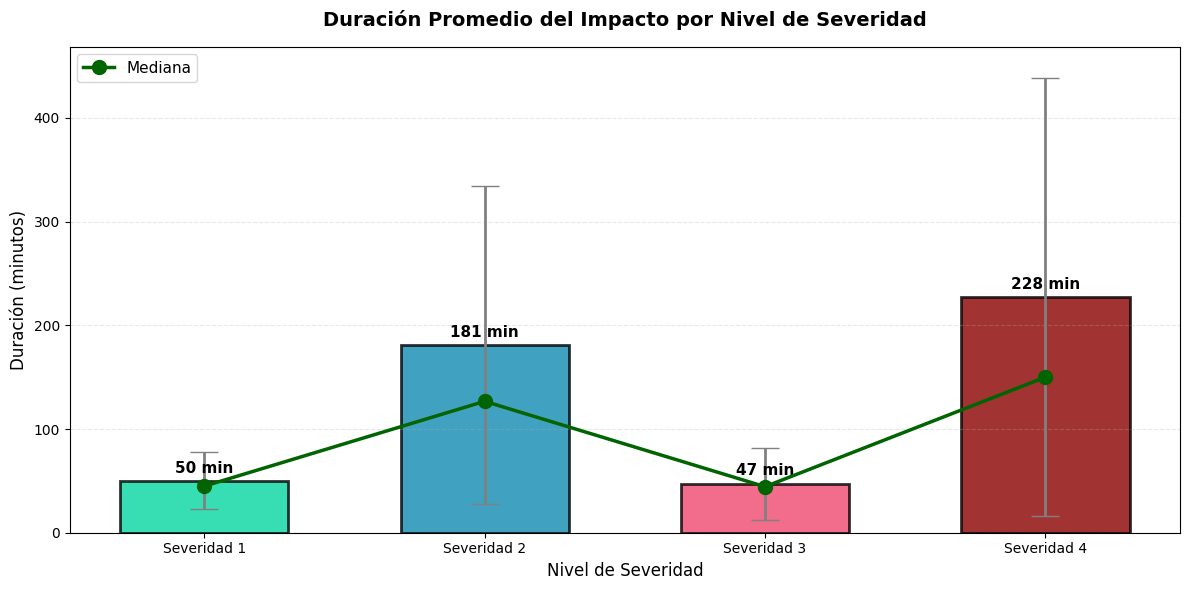

In [20]:
#C) Gráfico de barras - Duración promedio por severidad
plt.figure(figsize=(12, 6))

#Calcular estadísticas por severidad
severity_stats = df.groupby('Severity')['Duration_Minutes'].agg(['mean', 'median', 'std']).round(1)

#Crear gráfico de barras
x_pos = [1, 2, 3, 4]
colors = ['#06D6A0', '#118AB2', '#EF476F', '#8B0000']

bars = plt.bar(x_pos, severity_stats['mean'],
               width=0.6,
               color=colors,
               alpha=0.8,
               edgecolor='black',
               linewidth=2,
               yerr=severity_stats['std'],  # Barras de error (desviación estándar)
               capsize=10,
               error_kw={'linewidth': 2, 'ecolor': 'gray'})

#Agregar valores sobre las barras
for i, (pos, mean_val) in enumerate(zip(x_pos, severity_stats['mean'])):
    plt.text(pos, mean_val + 5, f'{mean_val:.0f} min',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

#Agregar línea de mediana
plt.plot(x_pos, severity_stats['median'], 'o-',
         color='darkgreen', linewidth=2.5, markersize=10,
         label='Mediana', zorder=5)

#Configuración
plt.title('Duración Promedio del Impacto por Nivel de Severidad',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nivel de Severidad', fontsize=12)
plt.ylabel('Duración (minutos)', fontsize=12)
plt.xticks(x_pos, ['Severidad 1', 'Severidad 2', 'Severidad 3', 'Severidad 4'])
plt.ylim(0, max(severity_stats['mean']) + max(severity_stats['std']) + 30)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('duracion_por_severidad.png', dpi=300, bbox_inches='tight')


In [21]:
#Mostrar tabla de estadísticas
print("\n   ESTADÍSTICAS POR SEVERIDAD:")

print(f"   {'Severidad':<12} {'Media':<12} {'Mediana':<12} {'Desv. Est.':<12}")
print("   " + "-"*70)
for sev in [1, 2, 3, 4]:
    print(f"   {'Nivel ' + str(sev):<12} {severity_stats.loc[sev, 'mean']:<12.1f} "
          f"{severity_stats.loc[sev, 'median']:<12.1f} {severity_stats.loc[sev, 'std']:<12.1f}")


   ESTADÍSTICAS POR SEVERIDAD:
   Severidad    Media        Mediana      Desv. Est.  
   ----------------------------------------------------------------------
   Nivel 1      50.1         44.9         27.3        
   Nivel 2      181.2        126.7        153.5       
   Nivel 3      47.3         44.4         34.8        
   Nivel 4      227.5        150.0        211.0       


El análisis reveló un patrón no lineal e inesperado en la relación entre duración y severidad.

Las estadísticas descriptivas muestran que la Severidad 4 tiene la mayor duración promedio (227.5 minutos) con mediana de 150.0 minutos y alta variabilidad (desv. est. 211.0), seguida sorprendentemente por Severidad 2 con 181.2 minutos de promedio (mediana 126.7, desv. est. 153.5), mientras que Severidades 1 y 3 presentan duraciones similares y mucho menores con promedios de 50.1 y 47.3 minutos respectivamente (medianas ~44 minutos, desv. est. ~30).


El gráfico de barras con línea de mediana visualiza claramente este patrón irregular donde Severidad 2 rompe la expectativa de una relación creciente monotónica, sugiriendo que factores operacionales como tipo de vía, disponibilidad de rutas alternativas o recursos de emergencia influyen más que la severidad física. Las barras de error (desviación estándar) especialmente amplias en Severidades 2 y 4 indican enorme variabilidad dentro de cada categoría, explicando por qué las correlaciones resultaron débiles:

* Pearson r = 0.005
* Spearman ρ = -0.066

 (ambas estadísticamente significativas con p = 0.0000 pero prácticamente insignificantes en magnitud), clasificándose como correlación débil según criterios estándar, lo que confirma que la duración del impacto no puede predecirse confiablemente solo con el nivel de severidad del accidente.

# 9) ¿Existen diferencias significativas entre accidentes urbanos y rurales?

Esta pregunta investiga si el contexto geográfico donde ocurren los accidentes (urbano, suburbano o rural) genera diferencias significativas en características clave como severidad, duración del impacto, densidad de infraestructura y nivel de riesgo.

Para responder esta interrogante, se realiza una comparación estadística completa que segmenta el dataset según la clasificación Urban_Rural creada previamente y calcula métricas descriptivas para cada categoría:

* Cantidad absoluta y porcentaje de accidentes

* severidad media y mediana para evaluar la gravedad típica

* duración media del impacto para medir el tiempo de afectación al tráfico

* POI Count medio que refleja la complejidad de infraestructura vial cercana

* distancia media afectada que indica la extensión del impacto

* porcentaje de accidentes de alta severidad (niveles 3-4) para identificar áreas más peligrosas

* Risk Score medio que integra múltiples factores de riesgo.

Esta comparación multidimensional permitirá determinar si las áreas urbanas, con mayor densidad de tráfico e infraestructura compleja, presentan patrones de accidentalidad fundamentalmente diferentes a las áreas rurales, donde predominan velocidades más altas y menor acceso a servicios de emergencia, y si las áreas suburbanas representan una categoría intermedia o tienen características propias distintivas.

In [22]:
print("PREGUNTA 9: Diferencias Urbano vs Rural")

#A) Comparación estadística completa
urban = df[df['Urban_Rural'] == 'Urbano']
suburban = df[df['Urban_Rural'] == 'Suburbano']
rural = df[df['Urban_Rural'] == 'Rural']

comparison_df = pd.DataFrame({
    'Métrica': ['Cantidad', 'Porcentaje', 'Severidad Media', 'Severidad Mediana',
                'Duración Media (min)', 'POI Count Medio', 'Distancia Media (mi)',
                '% Severidad Alta (3-4)', 'Risk Score Medio'],
    'Urbano': [
        len(urban),
        len(urban)/len(df)*100,
        urban['Severity'].mean(),
        urban['Severity'].median(),
        urban['Duration_Minutes'].mean(),
        urban['POI_Count'].mean(),
        urban['Distance(mi)'].mean(),
        (urban['Severity'] >= 3).sum() / len(urban) * 100,
        urban['Risk_Score'].mean()
    ],
    'Suburbano': [
        len(suburban),
        len(suburban)/len(df)*100,
        suburban['Severity'].mean(),
        suburban['Severity'].median(),
        suburban['Duration_Minutes'].mean(),
        suburban['POI_Count'].mean(),
        suburban['Distance(mi)'].mean(),
        (suburban['Severity'] >= 3).sum() / len(suburban) * 100,
        suburban['Risk_Score'].mean()
    ],
    'Rural': [
        len(rural),
        len(rural)/len(df)*100,
        rural['Severity'].mean(),
        rural['Severity'].median(),
        rural['Duration_Minutes'].mean(),
        rural['POI_Count'].mean(),
        rural['Distance(mi)'].mean(),
        (rural['Severity'] >= 3).sum() / len(rural) * 100,
        rural['Risk_Score'].mean()
    ]
}).round(2)

print("\n1. COMPARACIÓN ESTADÍSTICA COMPLETA:")
print(comparison_df.to_string(index=False))

PREGUNTA 9: Diferencias Urbano vs Rural

1. COMPARACIÓN ESTADÍSTICA COMPLETA:
               Métrica    Urbano  Suburbano      Rural
              Cantidad 108459.00  285495.00 1368495.00
            Porcentaje      6.15      16.20      77.65
       Severidad Media      1.98       2.05       2.08
     Severidad Mediana      2.00       2.00       2.00
  Duración Media (min)    160.63     164.28     176.60
       POI Count Medio      2.24       1.05       0.02
  Distancia Media (mi)      0.09       0.34       1.11
% Severidad Alta (3-4)      3.15       5.51       7.46
      Risk Score Medio      2.14       1.25       1.29


El análisis comparativo revela diferencias marcadas entre los tres tipos de área:
# Distribución de accidentes:

* Rural: 77.65% (1,368,495 casos) - Domina el dataset
* Suburbano: 16.20% (285,495 casos)
* Urbano: 6.15% (108,459 casos) - Menor representación

# Severidad del accidente:

* Severidad media similar en los tres contextos: Urbano 1.98, Suburbano 2.05 Rural 2.08
* Medianas idénticas de 2.00 para todas las áreas
* % Severidad Alta (3-4): Rural 7.46% > Suburbano 5.51% > Urbano 3.15%

# Duración del impacto:

* Rural: 176.60 minutos - Mayor tiempo de resolución
* Suburbano: 164.28 minutos
* Urbano: 160.63 minutos - Resolución más rápida

# Complejidad de infraestructura:

* POI Count medio: Urbano 2.24 > Suburbano 1.05 > Rural 0.02
* Distancia afectada: Rural 1.11 mi > Suburbano 0.34 mi > Urbano 0.09 mi

# Nivel de riesgo:

* Risk Score medio: Urbano 2.14 > Rural 1.29 > Suburbano 1.25
* Accidentes urbanos involucran mayor acumulación de factores de riesgo

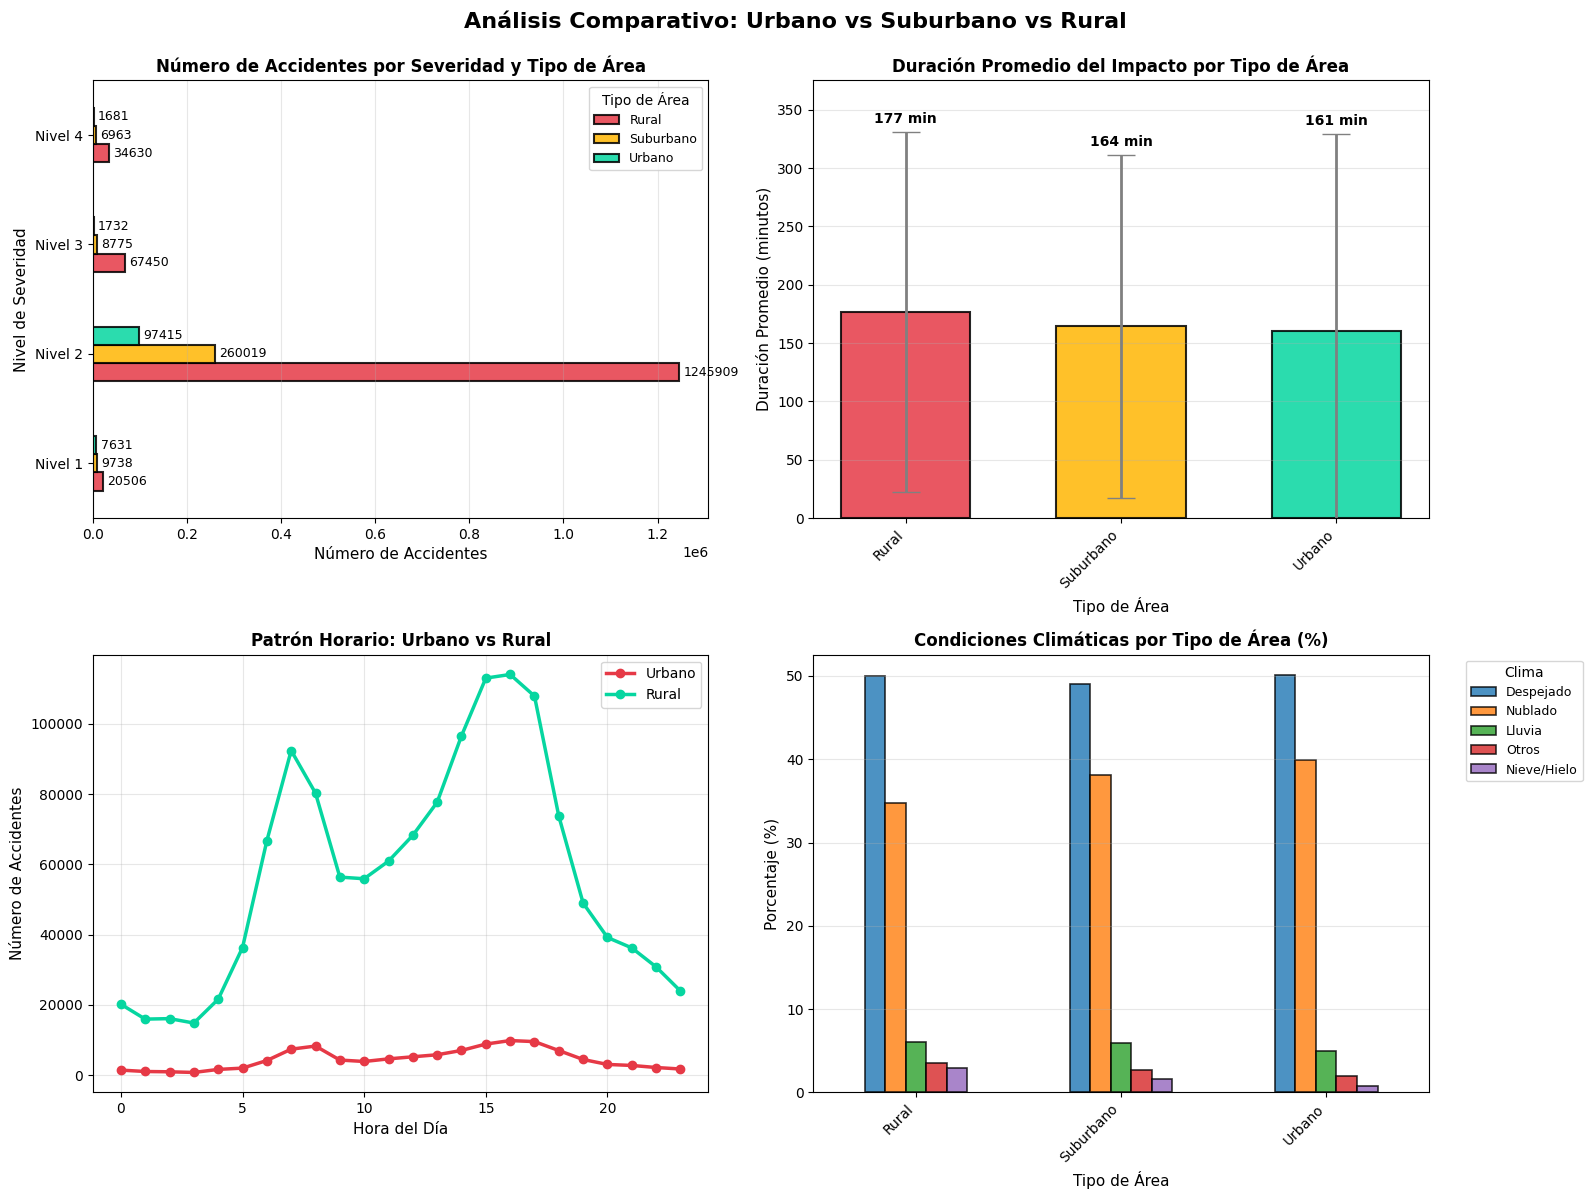

In [23]:
#B) Visualizaciones comparativas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#1. Barras agrupadas horizontales - MUCHO MÁS CLARO
severity_dist_abs = pd.crosstab(df['Urban_Rural'], df['Severity'])

#Transponer para que severidades sean las barras y áreas sean grupos
severity_by_area = severity_dist_abs.T

#Crear gráfico
severity_by_area.plot(kind='barh', ax=axes[0,0],
                      color=['#E63946', '#FFB703', '#06D6A0'],
                      alpha=0.85, edgecolor='black', linewidth=1.5)

axes[0,0].set_title('Número de Accidentes por Severidad y Tipo de Área',
                    fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Número de Accidentes', fontsize=11)
axes[0,0].set_ylabel('Nivel de Severidad', fontsize=11)
axes[0,0].legend(title='Tipo de Área', fontsize=9)
axes[0,0].set_yticklabels(['Nivel 1', 'Nivel 2', 'Nivel 3', 'Nivel 4'])
axes[0,0].grid(True, alpha=0.3, axis='x')

#Agregar valores en las barras
for container in axes[0,0].containers:
    axes[0,0].bar_label(container, fmt='%d', padding=3, fontsize=9)

#2. BARRAS - Duración promedio por tipo de área
duration_stats = df.groupby('Urban_Rural')['Duration_Minutes'].agg(['mean', 'std']).round(1)
areas = duration_stats.index
colors_areas = ['#E63946', '#FFB703', '#06D6A0']

bars = axes[0,1].bar(range(len(areas)), duration_stats['mean'],
                     width=0.6, color=colors_areas, alpha=0.85,
                     edgecolor='black', linewidth=1.5,
                     yerr=duration_stats['std'], capsize=10,
                     error_kw={'linewidth': 2, 'ecolor': 'gray'})

#Agregar valores sobre las barras
for i, (mean_val, std_val) in enumerate(zip(duration_stats['mean'], duration_stats['std'])):
    axes[0,1].text(i, mean_val + std_val + 5, f'{mean_val:.0f} min',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0,1].set_title('Duración Promedio del Impacto por Tipo de Área', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Tipo de Área', fontsize=11)
axes[0,1].set_ylabel('Duración Promedio (minutos)', fontsize=11)
axes[0,1].set_xticks(range(len(areas)))
axes[0,1].set_xticklabels(areas, rotation=45, ha='right')
axes[0,1].set_ylim(0, max(duration_stats['mean']) + max(duration_stats['std']) + 30)
axes[0,1].grid(True, alpha=0.3, axis='y')

#3. Patrón horario
for area_type, color in [('Urbano', '#E63946'), ('Rural', '#06D6A0')]:
    hourly = df[df['Urban_Rural']==area_type].groupby('Hour').size()
    axes[1,0].plot(hourly.index, hourly.values, marker='o', label=area_type,
                   linewidth=2.5, color=color, markersize=6)
axes[1,0].set_title('Patrón Horario: Urbano vs Rural', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Hora del Día', fontsize=11)
axes[1,0].set_ylabel('Número de Accidentes', fontsize=11)
axes[1,0].legend(fontsize=10)
axes[1,0].grid(True, alpha=0.3)

#4. Condiciones climáticas
weather_urban_rural = pd.crosstab(df['Urban_Rural'], df['Weather_Category'], normalize='index') * 100
top_weather = df['Weather_Category'].value_counts().head(5).index
weather_urban_rural[top_weather].plot(kind='bar', ax=axes[1,1], alpha=0.8,
                                       edgecolor='black', linewidth=1.2)
axes[1,1].set_title('Condiciones Climáticas por Tipo de Área (%)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Tipo de Área', fontsize=11)
axes[1,1].set_ylabel('Porcentaje (%)', fontsize=11)
axes[1,1].legend(title='Clima', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45, ha='right')
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Análisis Comparativo: Urbano vs Suburbano vs Rural',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('comparacion_urbano_rural.png', dpi=300, bbox_inches='tight')


Las cuatro visualizaciones presentadas revelan patrones distintivos entre tipos de área:

# Gráfico 1: Número de Accidentes por Severidad y Tipo de Área
Las áreas rurales dominan en valores absolutos todos los niveles de severidad, con el Nivel 2 concentrando 1,245,909 casos rurales versus 260,019 suburbanos y 97,415 urbanos, confirmando que la mayoría de accidentes ocurren en contextos rurales independientemente de la severidad.
# Gráfico 2: Duración Promedio del Impacto por Tipo de Área
Los accidentes rurales requieren mayor tiempo de resolución (177 min) comparado con suburbanos (164 min) y urbanos (161 min), con barras de error amplias indicando alta variabilidad relacionada con distancia a servicios de emergencia y disponibilidad de rutas alternativas.
# Gráfico 3: Patrón Horario Urbano vs Rural
Los accidentes rurales muestran un patrón bimodal con picos matutinos (7-8h) y vespertinos pronunciados (14-17h superando 110,000 casos), mientras que los urbanos mantienen volúmenes bajos (~10,000) con distribución más uniforme, sugiriendo que el tráfico rural está concentrado en horas pico específicas.
# Gráfico 4: Condiciones Climáticas por Tipo de Área (%)
Los tres tipos de área comparten patrón similar con predominio de Despejado (~50%) y Nublado (35-40%), con condiciones adversas (Lluvia ~6%, Nieve ~2%) consistentemente bajas en todos los contextos, indicando que las diferencias no están determinadas por variaciones climáticas sino por factores estructurales y operacionales.

In [24]:
import plotly.express as px

sample_areas = df.groupby('Urban_Rural').apply(
    lambda x: x.sample(min(5000, len(x)), random_state=42)
).reset_index(drop=True)

fig = px.scatter_geo(
    sample_areas,
    lat='Start_Lat',
    lon='Start_Lng',
    color='Severity',
    facet_col='Urban_Rural',
    facet_col_wrap=3,
    scope='usa',
    title='Distribución Geográfica: Urbano vs Suburbano vs Rural',
    color_continuous_scale='Reds'
)

fig.update_geos(showcountries=True, showland=True, landcolor='lightgray')
fig.update_layout(height=500)
fig.show()

/tmp/ipython-input-3015400689.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_areas = df.groupby('Urban_Rural').apply(


# Geográfica por Tipo de Área
Este mapa interactivo creado con Plotly Express presenta tres paneles comparativos que muestran la distribución espacial de accidentes según tipo de área (Rural, Suburbano, Urbano) a lo largo del territorio de Estados Unidos:
# Mapa 1: Urban_Rural = Rural
Muestra una concentración masiva de puntos dispersos por todo el territorio, especialmente densos en la costa este (corredor Nueva York-Boston-Washington), región de los Grandes Lagos (Chicago, Detroit), Texas (Dallas-Houston), y California (Los Ángeles-San Francisco). Los puntos rojos más oscuros (severidad 3-4) se observan principalmente en áreas metropolitanas del sur y este, mientras que la mayoría de puntos son tonos naranjas claros (severidad 1-2), confirmando que los accidentes rurales dominan el dataset en cobertura geográfica.
# Mapa 2: Urban_Rural = Suburbano
Presenta una distribución más concentrada alrededor de áreas metropolitanas específicas, con clusters notables en el noreste (Nueva York, Boston), medio oeste (Chicago, Indianapolis) y sur (Atlanta, Charlotte). La densidad de puntos es significativamente menor que en el mapa rural, con puntos predominantemente naranjas claros, indicando que los accidentes suburbanos se agrupan en las periferias de grandes ciudades y son mayoritariamente de severidad baja.
# Mapa 3: Urban_Rural = Urbano
Exhibe la menor cantidad de puntos, altamente localizados en núcleos metropolitanos específicos como Chicago, áreas del noreste y algunas ciudades del sur. Los puntos están más espaciados y se concentran en zonas urbanas densas, con predominio de tonos naranjas y algunos puntos rojos oscuros (severidad alta) particularmente visibles en el medio oeste, confirmando que aunque los accidentes urbanos son menos frecuentes, tienden a ocurrir en ubicaciones muy específicas de alta complejidad vial.
Interpretación general: La visualización geográfica confirma que la clasificación Urban_Rural captura efectivamente diferencias espaciales, con rurales cubriendo extensamente el territorio (especialmente autopistas interestatales), suburbanos formando anillos alrededor de metrópolis, y urbanos concentrados en núcleos citadinos específicos, validando la lógica de clasificación basada en distancia y POI Count.

# 10) ¿Qué combinaciones de factores (clima + infraestructura + tiempo) son más frecuentes en accidentes severos?


En esta sección del análisis se buscó identificar cuántos accidentes catalogados como severos (aquellos con niveles de severidad 3 y 4) existen dentro del conjunto total de datos, así como determinar qué porcentaje representan respecto al total de accidentes registrados.

Para esto se aplicó un filtro sobre la columna Severity, seleccionando únicamente los registros con valores mayores o iguales a 3, ya que estos niveles indican incidentes con impacto significativo en el tráfico, mayor duración del evento y posibles implicaciones críticas en la movilidad urbana.

Esta etapa cumple dos objetivos fundamentales:

1. Delimitar el subconjunto de accidentes severos sobre el cual se realizarán las combinaciones posteriores de factores (clima, infraestructura y tiempo).

2. Proporcionar contexto estadístico sobre la magnitud del problema, mostrando cuántos accidentes graves ocurren y qué tan representativos son en comparación con todos los eventos reportados.

In [25]:
print("PREGUNTA 10: Combinaciones de Factores en Accidentes Severos")

#Filtrar solo accidentes severos (Severidad >= 3)
df_severe = df[df['Severity'] >= 3].copy()
print(f"\n   Total de accidentes severos (Severidad 3-4): {len(df_severe):,}")
print(f"   Porcentaje del total: {len(df_severe)/len(df)*100:.1f}%")

PREGUNTA 10: Combinaciones de Factores en Accidentes Severos

   Total de accidentes severos (Severidad 3-4): 121,231
   Porcentaje del total: 6.9%


Los resultados obtenidos indican:

* Total de accidentes severos: 121,231

* Porcentaje respecto al total: ~6.9%

Este valor confirma que, aunque la mayoría de los accidentes no son severos, existe un porcentaje considerable que sí presenta riesgo elevado. Por ello es relevante analizar posteriormente qué combinaciones de factores (clima + infraestructura + tiempo) están más asociadas a estos incidentes graves.


1. COMBINACIÓN: CLIMA × ILUMINACIÓN (DÍA/NOCHE)

   Top 10 combinaciones más frecuentes:
    1. Despejado + Day: 39,542 accidentes (32.6%)
    2. Nublado + Day: 32,956 accidentes (27.2%)
    3. Despejado + Night: 17,552 accidentes (14.5%)
    4. Nublado + Night: 11,846 accidentes (9.8%)
    5. Lluvia + Day: 5,627 accidentes (4.6%)
    6. Otros + Day: 3,274 accidentes (2.7%)
    7. Lluvia + Night: 2,583 accidentes (2.1%)
    8. Nieve/Hielo + Day: 2,070 accidentes (1.7%)
    9. Tormenta + Day: 1,420 accidentes (1.2%)
   10. Otros + Night: 1,327 accidentes (1.1%)


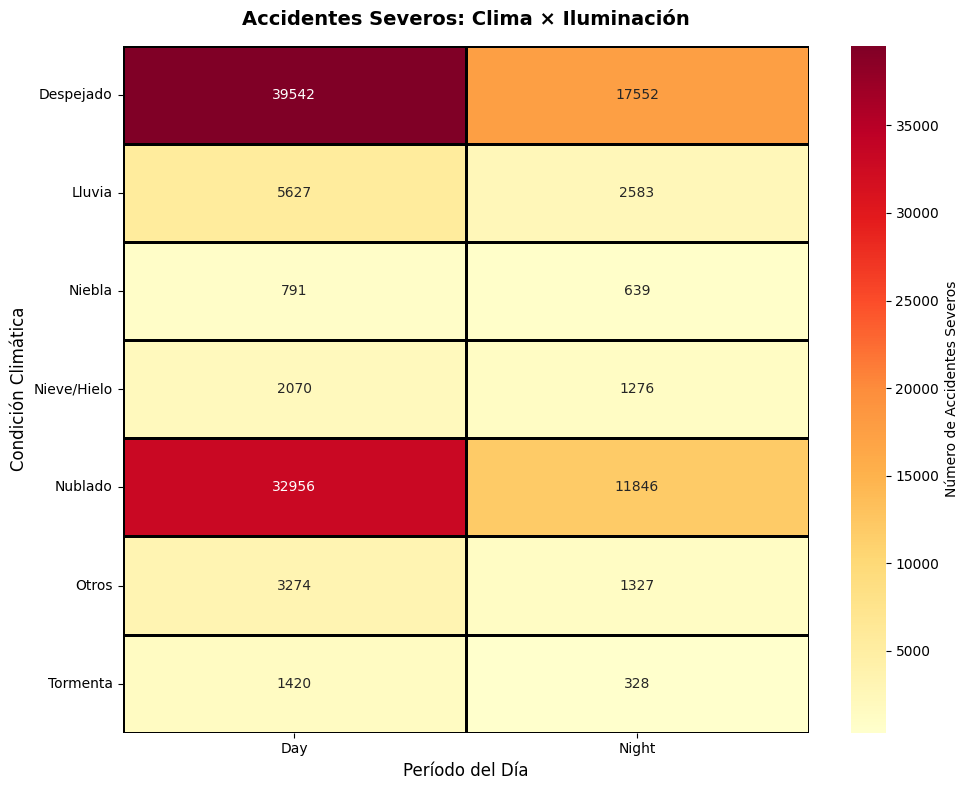

In [26]:
#A) Combinación 1: Weather_Category + Sunrise_Sunset
print("\n1. COMBINACIÓN: CLIMA × ILUMINACIÓN (DÍA/NOCHE)")
print("   " + "="*70)

weather_light = pd.crosstab(df_severe['Weather_Category'],
                             df_severe['Sunrise_Sunset'])

print("\n   Top 10 combinaciones más frecuentes:")
weather_light_flat = weather_light.stack().sort_values(ascending=False).head(10)
for i, ((weather, light), count) in enumerate(weather_light_flat.items(), 1):
    pct = count / len(df_severe) * 100
    print(f"   {i:2d}. {weather} + {light}: {count:,} accidentes ({pct:.1f}%)")

#Crear heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(weather_light, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=1, linecolor='black',
            cbar_kws={'label': 'Número de Accidentes Severos'})
plt.title('Accidentes Severos: Clima × Iluminación',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Período del Día', fontsize=12)
plt.ylabel('Condición Climática', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_clima_iluminacion.png', dpi=300, bbox_inches='tight')


En esta parte del análisis se estudió cómo interactúan dos factores importantes en accidentes severos: la condición climática y el periodo del día (Day/Night).
Para ello se creó una tabla cruzada que muestra cuántos accidentes graves ocurren en cada combinación de clima e iluminación.

Luego, las combinaciones fueron ordenadas para identificar las más frecuentes. Los resultados muestran que:

* Despejado + Day y Nublado + Day son las combinaciones con mayor número de accidentes severos.

* Las combinaciones que ocurren de noche tienen menos incidentes, pero siguen siendo relevantes.

Finalmente, se generó un heatmap que visualiza estas cantidades de forma clara, permitiendo ver rápidamente qué escenarios presentan mayor riesgo.


2. COMBINACIÓN: DENSIDAD DE POIs × PERÍODO DEL DÍA

   Distribución por POI_Density y Período:
Periodo_Dia  Madrugada (0-6h)  Mañana (6-12h)  Tarde (12-18h)  Noche (18-24h)
POI_Density                                                                  
Alta                        2               7               2               4
Baja                     2444            6401            6686            4024
Media                      98             228             205             149
Sin POIs                10615           32253           37863           20250


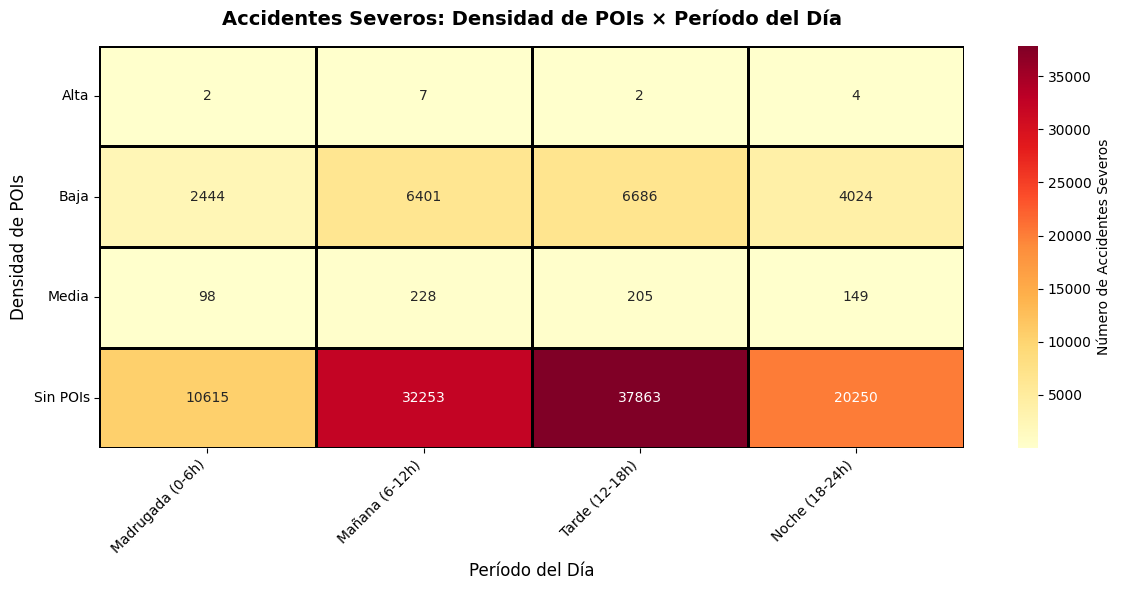

In [27]:
#B) Combinación 2: POI_Density + Periodo_Dia
print("\n2. COMBINACIÓN: DENSIDAD DE POIs × PERÍODO DEL DÍA")
print("   " + "="*70)

#Crear columna de período del día
def get_period(hour):
    if 0 <= hour < 6:
        return 'Madrugada (0-6h)'
    elif 6 <= hour < 12:
        return 'Mañana (6-12h)'
    elif 12 <= hour < 18:
        return 'Tarde (12-18h)'
    else:
        return 'Noche (18-24h)'

df_severe['Periodo_Dia'] = df_severe['Hour'].apply(get_period)

#Crear crosstab
poi_period = pd.crosstab(df_severe['POI_Density'],
                         df_severe['Periodo_Dia'])

#Verificar qué columnas existen antes de ordenar
period_order = ['Madrugada (0-6h)', 'Mañana (6-12h)', 'Tarde (12-18h)', 'Noche (18-24h)']
available_periods = [p for p in period_order if p in poi_period.columns]
poi_period = poi_period[available_periods]

print("\n   Distribución por POI_Density y Período:")
print(poi_period)

#Crear heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(poi_period, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=1, linecolor='black',
            cbar_kws={'label': 'Número de Accidentes Severos'})
plt.title('Accidentes Severos: Densidad de POIs × Período del Día',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Período del Día', fontsize=12)
plt.ylabel('Densidad de POIs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_poi_periodo.png', dpi=300, bbox_inches='tight')



En esta sección se analizó cómo influye la densidad de POIs (Points of Interest) del área como tiendas, servicios, locales, etc. combinada con el periodo del día, en la ocurrencia de accidentes severos.

Primero se construyó una tabla que muestra cuántos accidentes graves ocurren en zonas con:

* Alta densidad de POIs

* Media densidad

* Baja densidad

* Zonas sin POIs cercanos

y cómo estas cantidades varían según el horario: madrugada, mañana, tarde y noche.

Los resultados indican que:

* La mayoría de accidentes severos ocurre en zonas sin POIs, especialmente en mañana (6–12h) y tarde (12–18h).

* Las zonas con baja densidad presentan valores moderados.

* Las zonas con densidad media y alta muestran cantidades muy bajas, casi irrelevantes.

El heatmap permite visualizar este patrón con claridad:
los colores más intensos se concentran en “Sin POIs”, sobre todo durante horarios de mayor tráfico.


3. COMBINACIÓN: REGIÓN × CLIMA

   Top 3 condiciones climáticas por región:

   South:
      1. Despejado: 24,787 (44.4%)
      2. Nublado: 22,424 (40.2%)
      3. Lluvia: 4,135 (7.4%)

   West:
      1. Despejado: 16,548 (61.9%)
      2. Nublado: 6,981 (26.1%)
      3. Otros: 1,476 (5.5%)

   Midwest:
      1. Nublado: 8,104 (39.9%)
      2. Despejado: 8,042 (39.6%)
      3. Nieve/Hielo: 1,588 (7.8%)

   Northeast:
      1. Despejado: 7,717 (42.0%)
      2. Nublado: 7,293 (39.7%)
      3. Lluvia: 1,693 (9.2%)


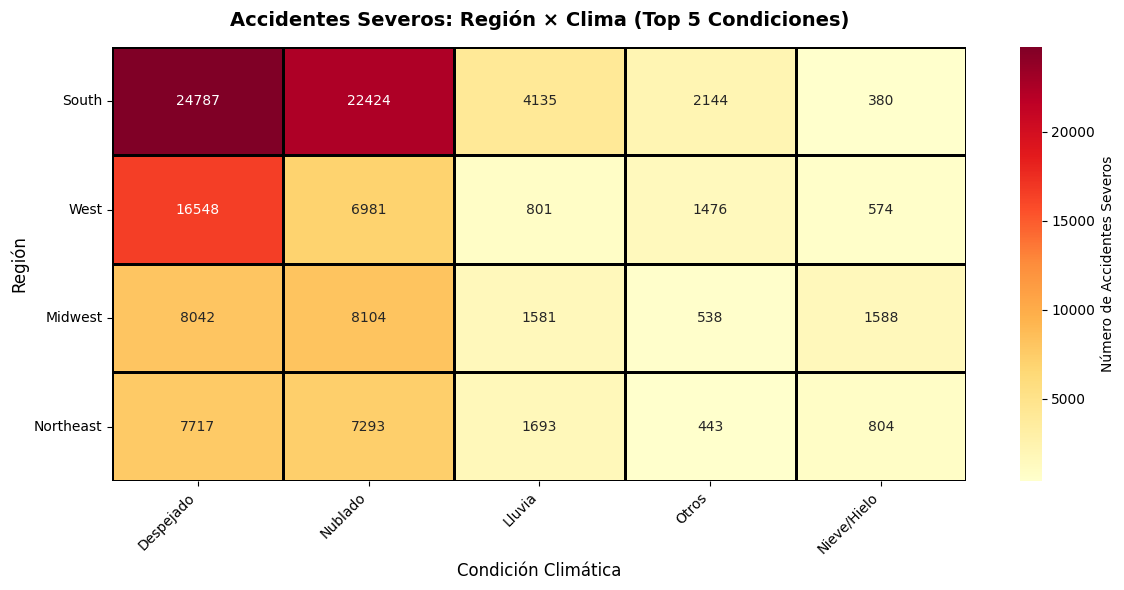

In [28]:
#C) Combinación 3: Region + Weather_Category
print("\n3. COMBINACIÓN: REGIÓN × CLIMA")
print("   " + "="*70)

region_weather = pd.crosstab(df_severe['Region'],
                              df_severe['Weather_Category'])

#Ordenar por total
region_weather['Total'] = region_weather.sum(axis=1)
region_weather = region_weather.sort_values('Total', ascending=False)
region_weather = region_weather.drop('Total', axis=1)

print("\n   Top 3 condiciones climáticas por región:")
for region in region_weather.index:
    print(f"\n   {region}:")
    region_data = region_weather.loc[region].sort_values(ascending=False).head(3)
    for i, (weather, count) in enumerate(region_data.items(), 1):
        pct = count / region_weather.loc[region].sum() * 100
        print(f"      {i}. {weather}: {count:,} ({pct:.1f}%)")

#Crear heatmap solo con top 5 climas
top_5_weather = df_severe['Weather_Category'].value_counts().head(5).index
plt.figure(figsize=(12, 6))
region_weather_top = region_weather[top_5_weather]
sns.heatmap(region_weather_top, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=1, linecolor='black',
            cbar_kws={'label': 'Número de Accidentes Severos'})
plt.title('Accidentes Severos: Región × Clima (Top 5 Condiciones)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Condición Climática', fontsize=12)
plt.ylabel('Región', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_region_clima.png', dpi=300, bbox_inches='tight')


En este análisis se estudió cómo varían los accidentes severos según la región del país y las condiciones climáticas más frecuentes. Para ello se elaboró una tabla que muestra los cinco tipos de clima principales por cada región y se identificaron las tres condiciones más comunes en cada una.

Los resultados muestran un patrón muy claro:

* En todas las regiones, los accidentes severos se concentran principalmente en dos tipos de clima: Despejado y Nublado.

* La región South presenta el mayor número absoluto de accidentes severos bajo estas dos condiciones.

* Regiones como West, Midwest y Northeast mantienen una distribución similar, aunque con volúmenes menores.

* Condiciones como Nieve/Hielo, Otros o Lluvia representan una proporción mucho más baja de los incidentes.

El heatmap refuerza estas observaciones: las celdas de Despejado y Nublado, especialmente en South y West, muestran las cifras más altas.


4. COMBINACIÓN: TIPO DE ÁREA × CLIMA

   Distribución completa:
Weather_Category  Despejado  Lluvia  Niebla  Nieve/Hielo  Nublado  Otros  \
Urban_Rural                                                                
Rural                 47947    7027    1219         2920    37598   3840   
Suburbano              7554    1010     170          359     5872    592   
Urbano                 1593     173      41           67     1332    169   

Weather_Category  Tormenta  
Urban_Rural                 
Rural                 1529  
Suburbano              181  
Urbano                  38  


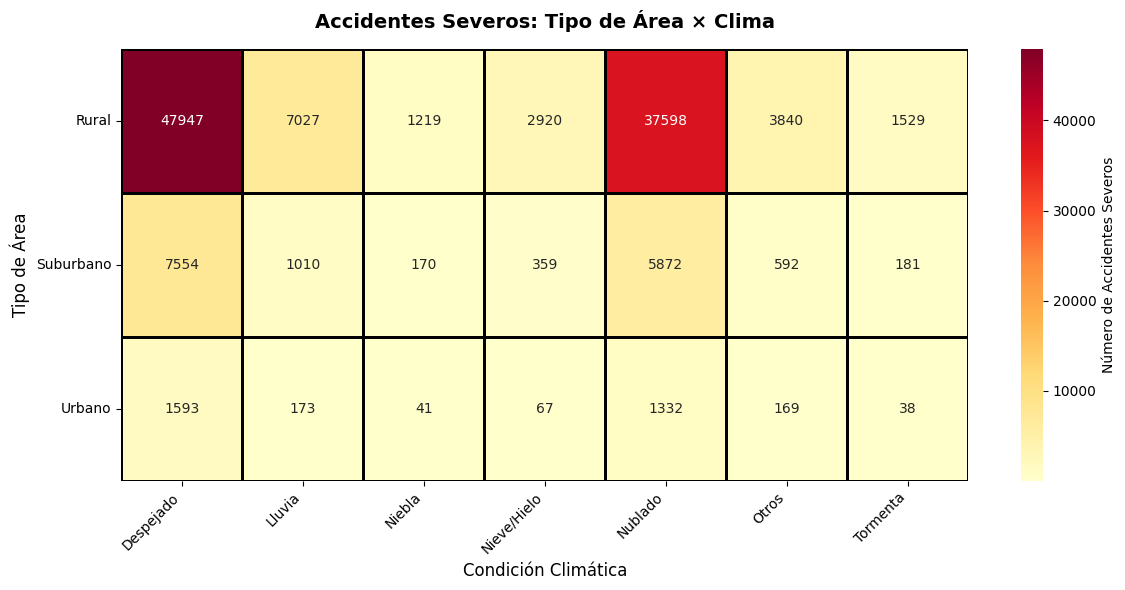

In [29]:
#D) Combinación 4: Urban_Rural + Weather_Category
print("\n4. COMBINACIÓN: TIPO DE ÁREA × CLIMA")
print("   " + "="*70)

area_weather = pd.crosstab(df_severe['Urban_Rural'],
                            df_severe['Weather_Category'])

print("\n   Distribución completa:")
print(area_weather)

#Crear heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(area_weather, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=1, linecolor='black',
            cbar_kws={'label': 'Número de Accidentes Severos'})
plt.title('Accidentes Severos: Tipo de Área × Clima',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Condición Climática', fontsize=12)
plt.ylabel('Tipo de Área', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_area_clima.png', dpi=300, bbox_inches='tight')



En este análisis se evaluó cómo se distribuyen los accidentes severos según el tipo de área (rural, suburbano y urbano) y las condiciones climáticas presentes al momento del accidente.
Se generó una tabla completa con el conteo de incidentes por clima en cada tipo de zona y se visualizó mediante un heatmap.

Los resultados muestran un patrón muy marcado:

* La mayoría de accidentes severos ocurren en zonas rurales, especialmente bajo clima Despejado y Nublado.

* Las zonas suburbanas muestran cifras menores, pero siguen el mismo patrón de concentrarse en climas despejados o nublados.

* Las zonas urbanas presentan el menor número de accidentes severos en todas las condiciones climáticas.

La visualización confirma que las celdas más intensas corresponden a Rural + Despejado y Rural + Nublado, indicando que los accidentes graves no se concentran en áreas con alta densidad urbana, sino en carreteras rurales donde las velocidades suelen ser más altas.

In [30]:
#E) Análisis de Triple Combinación: Área + Clima + Iluminación
print("\n5. ANÁLISIS TRIPLE: ÁREA × CLIMA × ILUMINACIÓN")
print("   " + "="*70)

#Top 15 combinaciones triples
triple_combo = df_severe.groupby(['Urban_Rural', 'Weather_Category',
                                   'Sunrise_Sunset']).size().sort_values(ascending=False).head(15)

print("\n   Top 15 combinaciones más peligrosas:")
for i, ((area, weather, light), count) in enumerate(triple_combo.items(), 1):
    pct = count / len(df_severe) * 100
    print(f"   {i:2d}. {area} + {weather} + {light}")
    print(f"       - {count:,} accidentes ({pct:.1f}%)")


5. ANÁLISIS TRIPLE: ÁREA × CLIMA × ILUMINACIÓN

   Top 15 combinaciones más peligrosas:
    1. Rural + Despejado + Day
       - 33,524 accidentes (27.7%)
    2. Rural + Nublado + Day
       - 27,886 accidentes (23.0%)
    3. Rural + Despejado + Night
       - 14,423 accidentes (11.9%)
    4. Rural + Nublado + Night
       - 9,712 accidentes (8.0%)
    5. Suburbano + Despejado + Day
       - 4,946 accidentes (4.1%)
    6. Rural + Lluvia + Day
       - 4,871 accidentes (4.0%)
    7. Suburbano + Nublado + Day
       - 4,122 accidentes (3.4%)
    8. Rural + Otros + Day
       - 2,727 accidentes (2.2%)
    9. Suburbano + Despejado + Night
       - 2,608 accidentes (2.2%)
   10. Rural + Lluvia + Night
       - 2,156 accidentes (1.8%)
   11. Rural + Nieve/Hielo + Day
       - 1,835 accidentes (1.5%)
   12. Suburbano + Nublado + Night
       - 1,750 accidentes (1.4%)
   13. Rural + Tormenta + Day
       - 1,247 accidentes (1.0%)
   14. Rural + Otros + Night
       - 1,113 accidentes (0.9%)
  

En esta etapa se analizó una combinación simultánea de tres factores:
tipo de área (rural/suburbano/urbano), condición climática y periodo del día (Day/Night).
El objetivo fue identificar cuáles combinaciones triples concentran la mayor cantidad de accidentes severos.

Para ello, se realizó un groupby con las tres variables y se ordenaron las combinaciones según su número de accidentes, obteniendo las 15 más frecuentes.

Los resultados muestran un patrón muy claro:

* Las zonas rurales durante el día, bajo clima Despejado o Nublado, representan por amplio margen las combinaciones con más accidentes severos.

* El horario Day domina prácticamente todas las combinaciones peligrosas, lo que coincide con los horarios de mayor flujo vehicular.

* Las zonas suburbanas aparecen en posiciones medias, mientras que las urbanas casi no figuran en el top, mostrando menor riesgo en esta triple interacción.

* Las combinaciones con clima adverso (lluvia, nieve/hielo, tormenta) aparecen, pero con porcentajes significativamente más bajos.

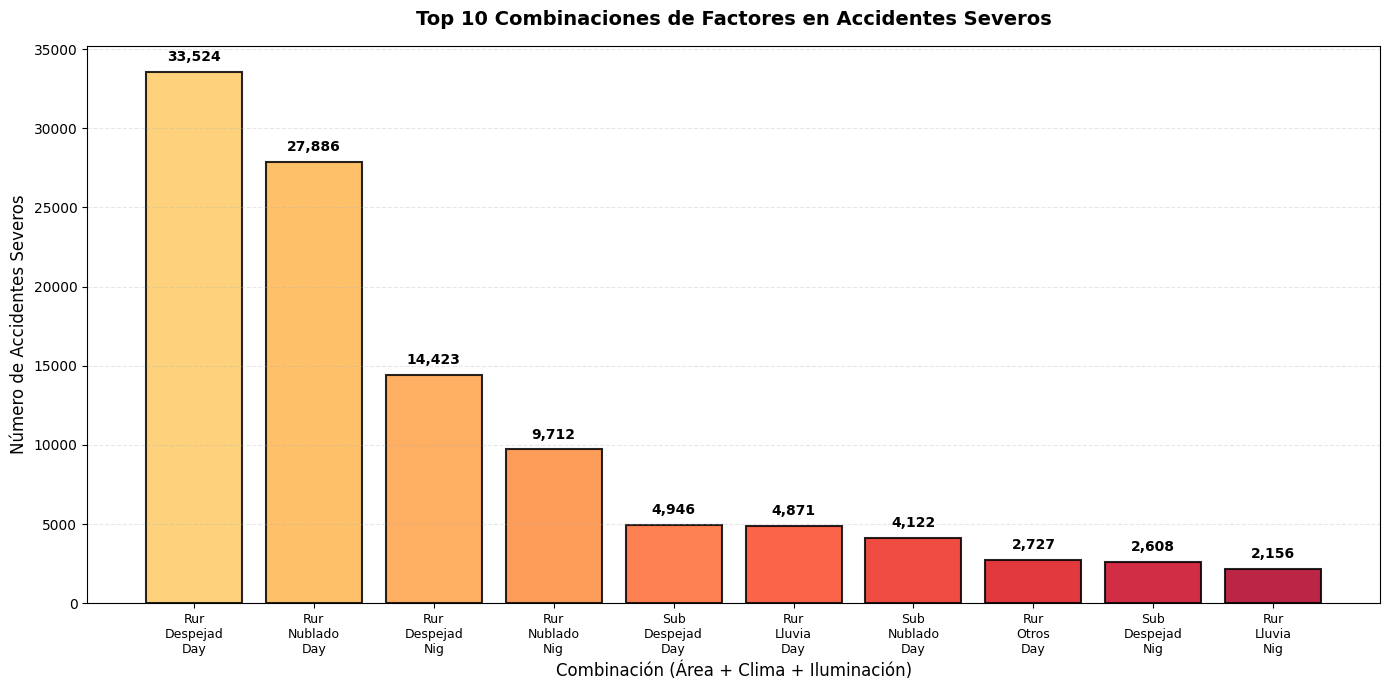

In [31]:
#F) Gráfico de Barras: Top 10 Combinaciones
#Crear labels descriptivos
top_10_combo = triple_combo.head(10)
labels = [f"{area[:3]}\n{weather[:8]}\n{light[:3]}"
          for (area, weather, light) in top_10_combo.index]

plt.figure(figsize=(14, 7))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, 10))

bars = plt.bar(range(10), top_10_combo.values, color=colors,
               alpha=0.85, edgecolor='black', linewidth=1.5)

#Agregar valores sobre las barras
for i, (bar, value) in enumerate(zip(bars, top_10_combo.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{value:,}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

plt.title('Top 10 Combinaciones de Factores en Accidentes Severos',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Combinación (Área + Clima + Iluminación)', fontsize=12)
plt.ylabel('Número de Accidentes Severos', fontsize=12)
plt.xticks(range(10), labels, fontsize=9, ha='center')
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('top_combinaciones_severos.png', dpi=300, bbox_inches='tight')


En esta parte se construyó un gráfico de barras que visualiza las 10 combinaciones triples más peligrosas, es decir, aquellas que registran el mayor número de accidentes severos considerando simultáneamente:

* Tipo de área (Rural, Suburbano, Urbano)

* Condición climática

* Iluminación (Day/Night)

El objetivo de este gráfico es presentar de manera comparativa cuáles combinaciones son las más críticas.

* Los resultados muestran claramente que:

* Las combinaciones más peligrosas por amplio margen son:

    * Rural + Despejado + Day

    * Rural + Nublado + Day

* Estas dos combinaciones superan ampliamente a cualquier otra, mostrando valores de 33k y 27k accidentes respectivamente.

* Otras combinaciones rurales durante la noche (Despejado/Nublado + Night) también aparecen, pero con cifras menores.

* Las zonas suburbanas solo comienzan a aparecer en posiciones intermedias, y las urbanas no se incluyen dentro del top 10.

In [34]:
#G ) Insights clave
print("INSIGHTS CLAVE - COMBINACIONES MÁS PELIGROSAS:")
print("   " + "="*70)

#Clima más peligroso
top_weather_severe = df_severe['Weather_Category'].value_counts().head(3)
print("\n   Condiciones climáticas más frecuentes en accidentes severos:")
for i, (weather, count) in enumerate(top_weather_severe.items(), 1):
    pct = count / len(df_severe) * 100
    print(f"   {i}. {weather}: {count:,} ({pct:.1f}%)")

#Período más peligroso
top_period_severe = df_severe['Periodo_Dia'].value_counts()
print("\n   Períodos más peligrosos:")
for i, (period, count) in enumerate(top_period_severe.items(), 1):
    pct = count / len(df_severe) * 100
    print(f"   {i}. {period}: {count:,} ({pct:.1f}%)")

#Tipo de área más peligroso
top_area_severe = df_severe['Urban_Rural'].value_counts()
print("\n   Distribución por tipo de área:")
for i, (area, count) in enumerate(top_area_severe.items(), 1):
    pct = count / len(df_severe) * 100
    print(f"   {i}. {area}: {count:,} ({pct:.1f}%)")

#Iluminación
top_light_severe = df_severe['Sunrise_Sunset'].value_counts()
print("\n   Distribución por iluminación:")
for light, count in top_light_severe.items():
    pct = count / len(df_severe) * 100
    print(f"   • {light}: {count:,} ({pct:.1f}%)")

INSIGHTS CLAVE - COMBINACIONES MÁS PELIGROSAS:

   Condiciones climáticas más frecuentes en accidentes severos:
   1. Despejado: 57,094 (47.1%)
   2. Nublado: 44,802 (37.0%)
   3. Lluvia: 8,210 (6.8%)

   Períodos más peligrosos:
   1. Tarde (12-18h): 44,756 (36.9%)
   2. Mañana (6-12h): 38,889 (32.1%)
   3. Noche (18-24h): 24,427 (20.1%)
   4. Madrugada (0-6h): 13,159 (10.9%)

   Distribución por tipo de área:
   1. Rural: 102,080 (84.2%)
   2. Suburbano: 15,738 (13.0%)
   3. Urbano: 3,413 (2.8%)

   Distribución por iluminación:
   • Day: 85,680 (70.7%)
   • Night: 35,551 (29.3%)


En esta sección se resumen los patrones más importantes identificados en todo el análisis, destacando los factores que aparecen con mayor frecuencia en los accidentes severos. Se presentan los insights por categoría: clima, horario, tipo de área e iluminación.

Los hallazgos principales son:

# 1. Condiciones climáticas más comunes en accidentes severos

La mayoría de los accidentes graves ocurren bajo climas normales, no extremos:

* Despejado (47.1%)

* Nublado (37.0%)

* Lluvia (6.8%)

Esto confirma que el mal clima no es el principal detonante de accidentes severos; el riesgo está presente incluso en condiciones favorables.

# 2. Períodos del día más peligrosos

Los accidentes severos se concentran en horarios de mayor actividad vehicular:

* Tarde (12–18h) – 36.9%

* Mañana (6–12h) – 32.1%

* Noche (18–24h) – 20.1%

* Madrugada (0–6h) – 10.9%

# 3. Tipo de área más afectado

Existe una diferencia marcada según el tipo de zona:

* Rural – 84.2%

* Suburbano – 13.0%

* Urbano – 2.8%

Las áreas rurales concentran la gran mayoría de accidentes severos, probablemente debido a mayores velocidades, menor supervisión y recorridos más largos.

# 4. Distribución por iluminación

La mayoría de accidentes severos ocurre durante el día:

* Day – 70.7%

* Night – 29.3%

Este patrón coincide con la distribución del tráfico: más circulación implica más exposición al riesgo.

In [35]:
#H) Correlaciones entre factores
print("CORRELACIONES ENTRE FACTORES CATEGÓRICOS:")
print("   " + "="*70)

#Calcular chi-cuadrado para independencia
from scipy.stats import chi2_contingency

#Test 1: Clima vs Iluminación
chi2_1, p_1, dof_1, expected_1 = chi2_contingency(weather_light)
print(f"\n   Clima × Iluminación:")
print(f"   - Chi-cuadrado: {chi2_1:.2f}")
print(f"   - P-valor: {p_1:.4f}")
if p_1 < 0.05:
    print(f"   • Conclusión: Existe relación significativa (p < 0.05)")
else:
    print(f"   • Conclusión: No hay relación significativa (p >= 0.05)")

#Test 2: Área vs Clima
chi2_2, p_2, dof_2, expected_2 = chi2_contingency(area_weather)
print(f"\n   Tipo de Área × Clima:")
print(f"   - Chi-cuadrado: {chi2_2:.2f}")
print(f"   - P-valor: {p_2:.4f}")
if p_2 < 0.05:
    print(f"   - Conclusión: Existe relación significativa (p < 0.05)")
else:
    print(f"   - Conclusión: No hay relación significativa (p >= 0.05)")


CORRELACIONES ENTRE FACTORES CATEGÓRICOS:

   Clima × Iluminación:
   - Chi-cuadrado: 635.93
   - P-valor: 0.0000
   • Conclusión: Existe relación significativa (p < 0.05)

   Tipo de Área × Clima:
   - Chi-cuadrado: 80.16
   - P-valor: 0.0000
   - Conclusión: Existe relación significativa (p < 0.05)


En esta sección se aplicó la prueba de independencia chi-cuadrado para evaluar si existe relación significativa entre algunos de los factores categóricos analizados en los accidentes severos.
La prueba permite determinar si dos variables categóricas están asociadas o si se comportan de manera independiente.

Se realizaron dos análisis:

1. Clima × Iluminación

Se evaluó si la condición climática está asociada al periodo del día (Day/Night).

Resultados:

* Chi-cuadrado: 635.93

* p-valor: 0.0000

Existe una relación significativa entre clima e iluminación (p < 0.05).
Esto significa que ciertos tipos de clima ocurren con mayor frecuencia en determinados periodos del día.

2. Tipo de Área × Clima

Se evaluó si el tipo de zona (rural, suburbano, urbano) influye en la distribución de condiciones climáticas durante los accidentes.

Resultados:

* Chi-cuadrado: 80.16

* p-valor: 0.0000

Existe una relación significativa entre tipo de área y clima (p < 0.05).
Esto indica que ciertas condiciones climáticas aparecen con más frecuencia en algunos tipos de áreas que en otros.

Las pruebas demuestran que los factores categóricos analizados no son independientes, sino que presentan asociaciones estadísticas relevantes.
Esto refuerza la idea de que las combinaciones de factores (clima, iluminación, área) deben analizarse en conjunto, ya que interactúan entre sí y afectan la ocurrencia de accidentes severos.